# cmQTL iPSC lines → AnnData

Induced pluripotent stem cell lines profiled for cell-morphology QTL mapping ([`cpg0022`](https://broadinstitute.github.io/cellpainting-gallery/)). Distributed as uncompressed CSV, and the obs are thin, so plate and batch are all there is to test against.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized.csv" \
  s3://cellpainting-gallery/cpg0022-cmqtl/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0022-cmqtl/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv"))
print(f"{len(files)} plates")

11 plates


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 4148 × 1444
    obs: 'Plate', 'Well', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "batch"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_RadialDistribution_RadialCV_Mito_4of4,nuclei,radialdistribution,mito,NaN,1
Nuclei_RadialDistribution_RadialCV_RNA_1of4,nuclei,radialdistribution,rna,NaN,1
Nuclei_RadialDistribution_RadialCV_RNA_2of4,nuclei,radialdistribution,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["batch"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

4,148 wells x 1,327 features
non-finite: 0 | max|x|: 388937.9

batch:
batch
2019_05_13_Batch2    768
2019_06_10_Batch3    768
2019_08_15_Batch4    753
2019_09_06_Batch5    715
2020_07_22_Batch7    384
PILOT_1              384


In [6]:
adata.write_h5ad(PROFILES.parent / "cmqtl.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["batch", "Plate"]))

,observed,baseline,ratio
covariate,,,
batch,0.584,0.157,3.733
Plate,0.529,0.091,5.806


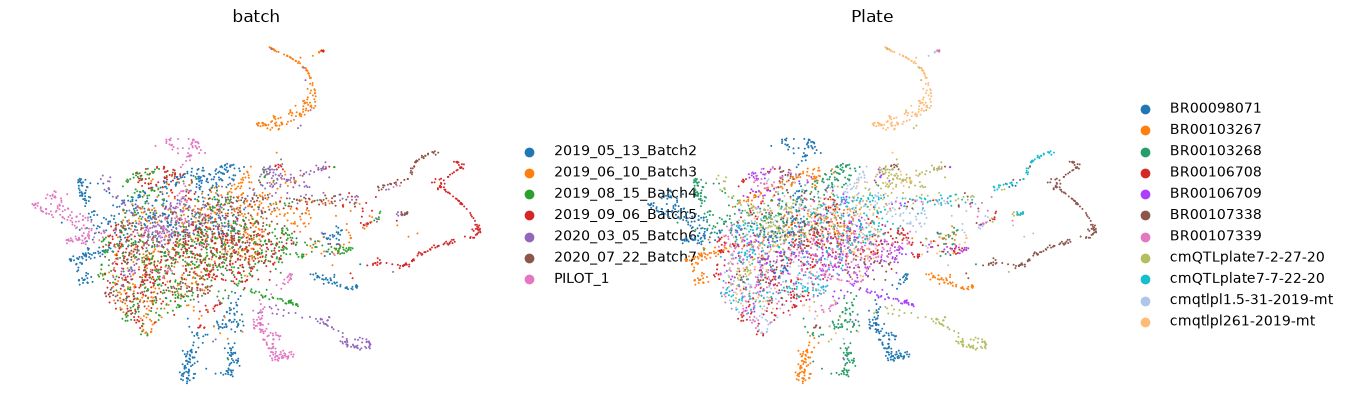

In [9]:
sc.pl.umap(adata, color=present(["batch", "Plate", "Count_Cells"])[:3], ncols=3, frameon=False, size=8)